### Agentic rag with langchain


In [32]:


import os
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document


In [33]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [64]:
##initialize the GEMINI API client
gemini_apikey = os.getenv("GEMINI_API_KEY")
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    google_api_key=gemini_apikey,
)
llm= ChatGoogleGenerativeAI(
    model="gemini-3.8-flash",
    temperature=0.2,
    google_api_key=gemini_apikey,
)


### State defination

In [47]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

### Sample documents

In [48]:
### Sample Docuemnt And VectorStore
# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

documents=[Document(page_content=text) for text in sample_texts]

##create vector store
vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(k=3)

### Agentic Funtions

In [49]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """
    question = state["question"]
    
    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)
    
    return {**state, "needs_retrieval": needs_retrieval}

In [50]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)
    
    return {**state, "documents": documents}

In [51]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])
    
    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:

Context:
{context}

Question: {question}

Answer:"""
    else:
        # Direct response without retrieval
        prompt = f"Answer the following question: {question}"
    
    response = llm.invoke(prompt)
    answer = response.content
    
    return {**state, "answer": answer}

### Conditional logic


In [52]:
def should_retrieve(state: AgentState) -> str:
    """determines whether retrieval is needed based on the current state"""
    if state["needs_retrieval"]:
        return "retrieve"
    else:return "generate"

### build graph

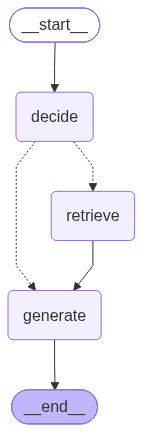

In [53]:
#create a state graph
workflow = StateGraph(AgentState)
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

#set entry point
workflow.set_entry_point("decide")

#conditional logic
workflow.add_conditional_edges("decide", should_retrieve, 
                               {
                                   "retrieve": "retrieve",
                                   "generate": "generate"
                               })

#add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

#compile the workflow
app = workflow.compile()
app

### testng 

In [54]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    
    result = app.invoke(initial_state)
    return result

In [55]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph?',
 'documents': [Document(id='177557ac-0153-4f95-a84f-cb7af239a578', metadata={}, page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.'),
  Document(id='9eca887a-97ab-4353-ab42-25c8aff825e2', metadata={}, page_content='RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.'),
  Document(id='64ac887b-0d71-41bd-9233-f69bc16965b4', metadata={}, page_content='Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.'),
  Document(id='483f7e4e-2f4d-4f5f-9f91-a924f8ae7fa4', metadata={}, page_content='Agentic system

In [65]:
# Test with another question
question2 = "How does RAG work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

Question: How does RAG work?
Retrieved documents: 4
Answer: [{'type': 'text', 'text': 'Based on the provided context, RAG works by combining information retrieval with text generation. It retrieves relevant documents (often using vector databases to find them based on semantic similarity) and uses those documents as context to generate more accurate responses.', 'extras': {'signature': 'EvEKCu4KAWkUfRNelLWxHhzSL0xC7BrRbw6RgAKftOCFcl9IVHycwVeJYrL0fLNiQihvNXOEMw+It1iRzR7RKv/amPuzNiM+mBXh1ZG6HbYQSQ8HEqUvm6E2GTuKBXcH801MuSviDCEabrSLf/77NVFcDcdcdROchW+45Rg68DP5B150dWDGVTgDG8XLoVc6dN5TSFrNWho7eKPsWHxDXziviF225mO6DxbnKSd9aClraWt/gaUvbHn+vCn1DfJGjzpsMm3GsVtklYTcyY8i775pDnMOa6PcuHfdBrrrySYusqPgupKhLPrWAIOYKi1pUABTSxHbvkC3JD02/aAZj5eBqq2cIZjMRBsKyuGx5dFgBulfzcjSmWvVzZwRKQaZ1AzDOTH/D77cNveGK3wlOSCS5TG0gikgIbZBlYJkERcISKVMyJduPMuaYSl0C4UMuFG7JZLVv1L8z4BdkgVJP0SHneioaZgbCO2DV74DddwqrGAHWxTkYnWgAzSiVm5OMgHI4YOOoFZciJMQPK+9tnWszzf2gbZTK63U4T3PGFzp/3uv7FAk7aAxG6lqVdiVB3HyLH7csUUclL+lmCvp947LD0PTOko915